In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.ticker as mticker
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [23]:
Heisenberg_ground_states = {"5": -8.472135954999581,
                            "6": -11.21110255092798,
                            "7": -12.420717027386775,
                            "8": -14.604373635748704,
                            "9": -16.189199135748044
                             }

In [24]:
import os
os.path.exists("../../data_folders/1DHeisenberg_Scalability_Rotosolve_L=5Q")

True

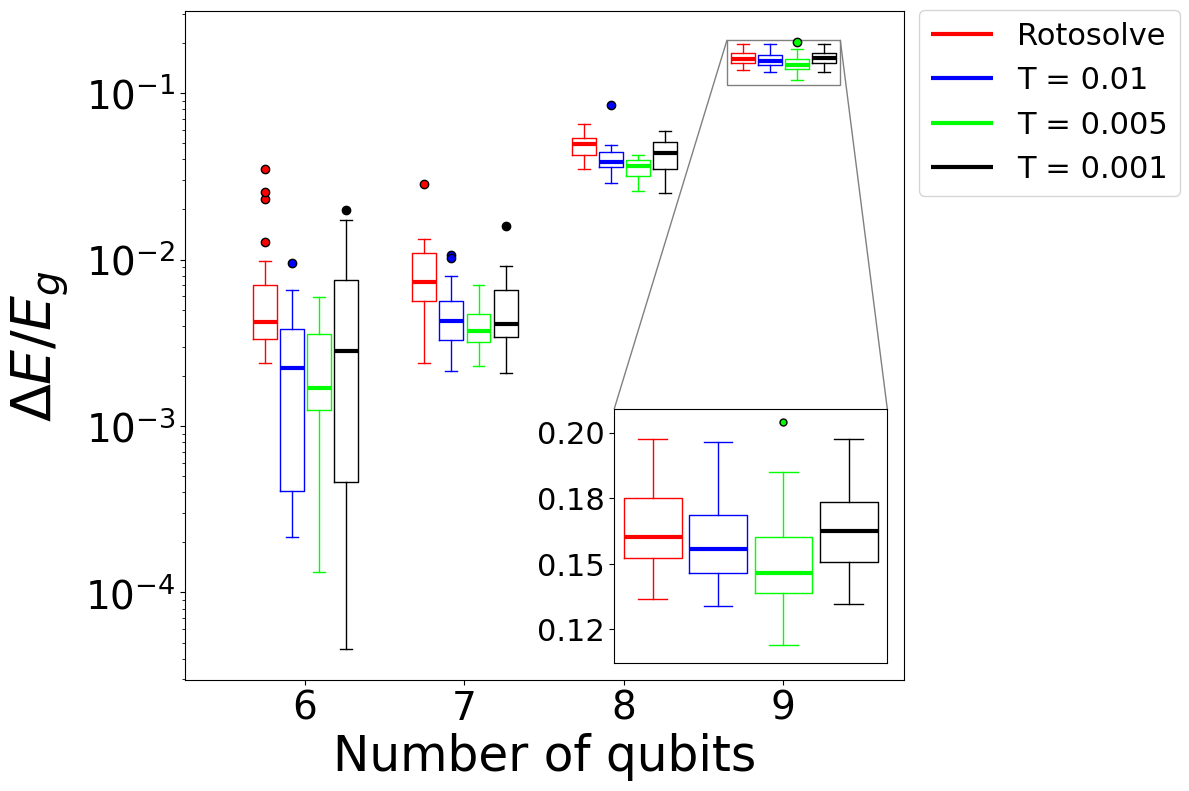

In [25]:
data_folder_L_5Q = f"../../data_folders/1DHeisenberg_Scalability_Rotosolve_L=5Q"

trials = 20
show_std = False

iters = 10

qubits = [6,7,8,9]

fig, ax = plt.subplots()

fig.set_figheight(8)
fig.set_figwidth(12)

colors = ["red", "blue", "lime", "black"]

labels = ["Rotosolve", "T = 0.01", "T = 0.005", "T = 0.001"]

xtiks = np.arange(6.25, qubits[-1]+1, 1)


df1 = pd.read_excel(f"{data_folder_L_5Q}/1DHeisenberg_rotosolve_{iters}cycles_{trials}trials_lastrows.xlsx")
df2 = pd.read_excel(f"{data_folder_L_5Q}/1DHeisenberg_rotosolve_GateFreeze_d0.01_{iters}cycles_{trials}trials_lastrows.xlsx")
df3 = pd.read_excel(f"{data_folder_L_5Q}/1DHeisenberg_rotosolve_GateFreeze_d0.005_{iters}cycles_{trials}trials_lastrows.xlsx")
df4 = pd.read_excel(f"{data_folder_L_5Q}/1DHeisenberg_rotosolve_GateFreeze_d0.001_{iters}cycles_{trials}trials_lastrows.xlsx")
    

errors_q9 = None
pos_q9 = None
    
for qubit in qubits:
    data1 = df1[f"{qubit}Q"]
    data2 = df2[f"{qubit}Q"]
    data3 = df3[f"{qubit}Q"]
    data4 = df4[f"{qubit}Q"]


    err1 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data1) / Heisenberg_ground_states[f"{qubit}"])
    err2 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data2) / Heisenberg_ground_states[f"{qubit}"])
    err3 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data3) / Heisenberg_ground_states[f"{qubit}"])
    err4 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data4) / Heisenberg_ground_states[f"{qubit}"])

    errors = [err1, err2, err3, err4]
    
    # store 9Q for inset
    if qubit == 9:
        errors_q9 = errors
        pos_q9 = [qubit + i*0.17 for i in range(len(errors))]

    for i, (dat, color, label) in enumerate(zip(errors, colors, labels), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                        markerfacecolor=color, markersize=7)
        
        if qubit == qubits[-1]:
            ax.boxplot(dat, positions=[qubit + i*0.17], widths=0.15,
                    patch_artist=False,
                    boxprops=dict(color=color, linewidth=1),      # Box color and thickness
                    capprops=dict(color=color, linewidth=1),                       # Cap color and thickness
                    whiskerprops=dict(color=color, linewidth=1),                   # Whisker color and thickness
                    medianprops=dict(color=color, linewidth=3),
                    meanprops=meanpointprops,
                    #showmeans=True,
                    flierprops = dict(markersize=6, markeredgecolor='black', markerfacecolor=color),
                    label= label
            )
        else:
            ax.boxplot(dat, positions=[qubit + i*0.17], widths=0.15,
                    patch_artist=False,
                    boxprops=dict(color=color, linewidth=1),      # Box color and thickness
                    capprops=dict(color=color, linewidth=1),                       # Cap color and thickness
                    whiskerprops=dict(color=color, linewidth=1),                   # Whisker color and thickness
                    medianprops=dict(color=color, linewidth=3),
                    meanprops=meanpointprops,
                    #showmeans=True,
                    flierprops = dict(markersize=6, markeredgecolor='black', markerfacecolor=color),
                    
            )


ax.set_xlabel("Number of qubits", fontsize = 35)
ax.set_ylabel(r"$\Delta E / E_g$", fontsize = 40, labelpad=10)
ax.set_yscale("log")

ax.set_xticks(xtiks, qubits)
ax.tick_params(labelsize=28)

ax.legend(loc='upper left', bbox_to_anchor=(1, 1.025), fontsize = 22)

axins = inset_axes(ax, width="38%", height="38%", loc="lower right", borderpad=1.2)

for i, (dat, color) in enumerate(zip(errors_q9, colors)):
    meanpointprops = dict(marker='D', markeredgecolor='black',
                          markerfacecolor=color, markersize=6)

    axins.boxplot(dat, positions=[pos_q9[i]], widths=0.15,
                  patch_artist=False,
                  boxprops=dict(color=color, linewidth=1),
                  capprops=dict(color=color, linewidth=1),
                  whiskerprops=dict(color=color, linewidth=1),
                  medianprops=dict(color=color, linewidth=3),
                  meanprops=meanpointprops,
                  flierprops=dict(markersize=5, markeredgecolor='black', markerfacecolor=color))

axins.set_yscale("log")

# Zoom results for 9 qubits
xmin, xmax = min(pos_q9) - 0.1, max(pos_q9) + 0.1
axins.set_xlim(xmin, xmax)
all_q9 = np.concatenate([np.asarray(e) for e in errors_q9])
all_q9 = all_q9[np.isfinite(all_q9) & (all_q9 > 0)]
ymin = np.quantile(all_q9, 0.05)
ymax = np.quantile(all_q9, 0.95)

axins.set_ylim(ymin / 1.2, ymax * 1.1)
axins.tick_params(labelsize=22)
axins.set_xlabel("")                          
axins.set_xticks([])                    
axins.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
axins.set_yscale("linear")                  
axins.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

mark_inset(ax, axins, loc1=1, loc2=2, fc="none", ec="0.5", lw=1)

fig.tight_layout()


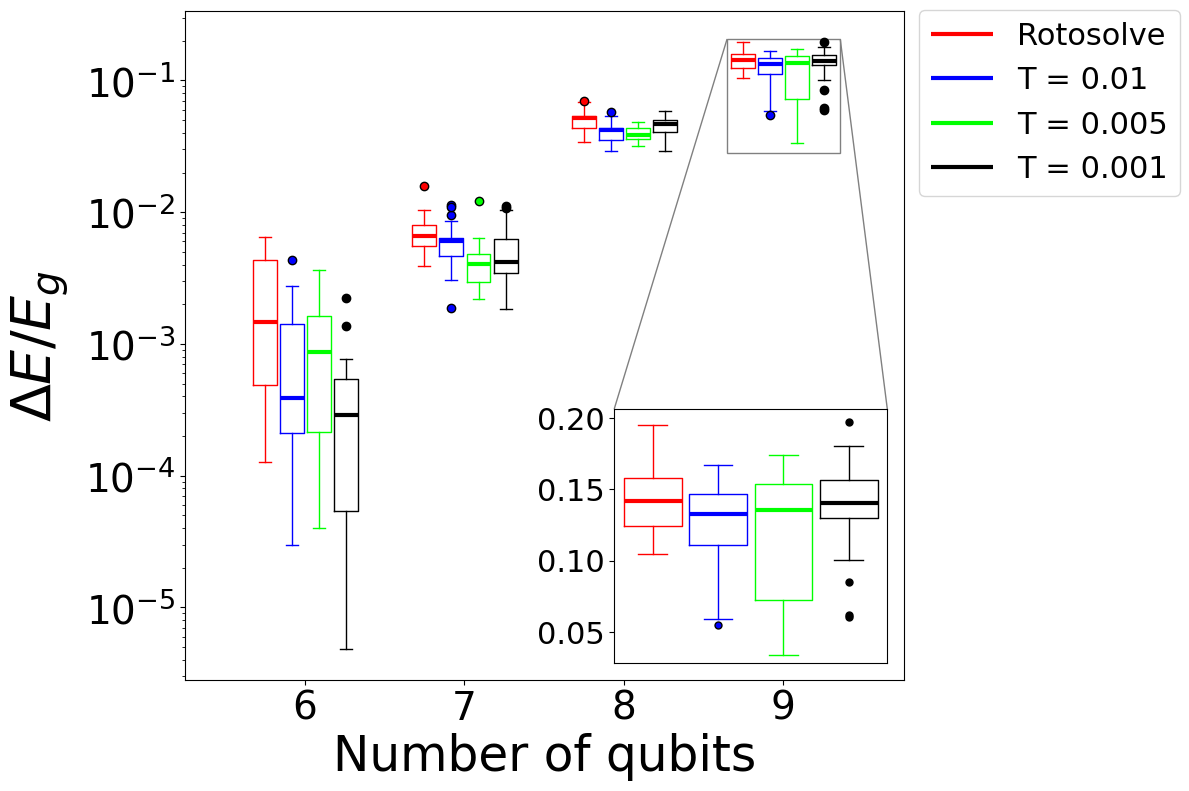

In [26]:
data_folder_L_10Q = f"../../data_folders/1DHeisenberg_Scalability_Rotosolve_L=10Q"


trials = 20
show_std = False

iters = 20

qubits = [6,7,8,9]

fig, ax = plt.subplots()

fig.set_figheight(8)
fig.set_figwidth(12)

colors = ["red", "blue", "lime", "black"]

labels = ["Rotosolve", "T = 0.01", "T = 0.005", "T = 0.001"]

xtiks = np.arange(6.25, qubits[-1]+1, 1)


df1 = pd.read_excel(f"{data_folder_L_10Q}/1DHeisenberg_rotosolve_{iters}cycles_{trials}trials_lastrows.xlsx")
df2 = pd.read_excel(f"{data_folder_L_10Q}/1DHeisenberg_rotosolve_GateFreeze_d0.01_{iters}cycles_{trials}trials_lastrows.xlsx")
df3 = pd.read_excel(f"{data_folder_L_10Q}/1DHeisenberg_rotosolve_GateFreeze_d0.005_{iters}cycles_{trials}trials_lastrows.xlsx")
df4 = pd.read_excel(f"{data_folder_L_10Q}/1DHeisenberg_rotosolve_GateFreeze_d0.001_{iters}cycles_{trials}trials_lastrows.xlsx")


for qubit in qubits:
    data1 = df1[f"{qubit}Q"]
    data2 = df2[f"{qubit}Q"]
    data3 = df3[f"{qubit}Q"]
    data4 = df4[f"{qubit}Q"]


    err1 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data1) / Heisenberg_ground_states[f"{qubit}"])
    err2 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data2) / Heisenberg_ground_states[f"{qubit}"])
    err3 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data3) / Heisenberg_ground_states[f"{qubit}"])
    err4 = np.abs((Heisenberg_ground_states[f"{qubit}"] - data4) / Heisenberg_ground_states[f"{qubit}"])

    errors = [err1, err2, err3, err4]

    # store 9Q for inset
    if qubit == 9:
        errors_q9 = errors
        pos_q9 = [qubit + i*0.17 for i in range(len(errors))]


    for i, (dat, color, label) in enumerate(zip(errors, colors, labels), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                        markerfacecolor=color, markersize=7)
        
        if qubit == qubits[-1]:
            ax.boxplot(dat, positions=[qubit + i*0.17], widths=0.15,
                    patch_artist=False,
                    boxprops=dict(color=color, linewidth=1),      # Box color and thickness
                    capprops=dict(color=color, linewidth=1),                       # Cap color and thickness
                    whiskerprops=dict(color=color, linewidth=1),                   # Whisker color and thickness
                    medianprops=dict(color=color, linewidth=3),
                    meanprops=meanpointprops,
                    #showmeans=True,
                    flierprops = dict(markersize=6, markeredgecolor='black', markerfacecolor=color),
                    label= label
            )
        else:
            ax.boxplot(dat, positions=[qubit + i*0.17], widths=0.15,
                    patch_artist=False,
                    boxprops=dict(color=color, linewidth=1),      # Box color and thickness
                    capprops=dict(color=color, linewidth=1),                       # Cap color and thickness
                    whiskerprops=dict(color=color, linewidth=1),                   # Whisker color and thickness
                    medianprops=dict(color=color, linewidth=3),
                    meanprops=meanpointprops,
                    #showmeans=True,
                    flierprops = dict(markersize=6, markeredgecolor='black', markerfacecolor=color),
                    
            )


ax.set_xlabel("Number of qubits", fontsize = 35)
ax.set_ylabel(r"$\Delta E / E_g$", fontsize = 40, labelpad=10)
ax.set_yscale("log")

ax.set_xticks(xtiks, qubits)
ax.tick_params(labelsize=28)

ax.legend(loc='upper left', bbox_to_anchor=(1, 1.025), fontsize = 22)


axins = inset_axes(ax, width="38%", height="38%", loc="lower right", borderpad=1.2)

for i, (dat, color) in enumerate(zip(errors_q9, colors)):
    meanpointprops = dict(marker='D', markeredgecolor='black',
                          markerfacecolor=color, markersize=6)

    axins.boxplot(dat, positions=[pos_q9[i]], widths=0.15,
                  patch_artist=False,
                  boxprops=dict(color=color, linewidth=1),
                  capprops=dict(color=color, linewidth=1),
                  whiskerprops=dict(color=color, linewidth=1),
                  medianprops=dict(color=color, linewidth=3),
                  meanprops=meanpointprops,
                  flierprops=dict(markersize=5, markeredgecolor='black', markerfacecolor=color))

axins.set_yscale("log")

xmin, xmax = min(pos_q9) - 0.1, max(pos_q9) + 0.1
axins.set_xlim(xmin, xmax)

all_q9 = np.concatenate([np.asarray(e) for e in errors_q9])
all_q9 = all_q9[np.isfinite(all_q9) & (all_q9 > 0)]
ymin = np.quantile(all_q9, 0.05)
ymax = np.quantile(all_q9, 0.95)

axins.set_ylim(ymin / 2.1, ymax * 1.2)
axins.tick_params(labelsize=22)
axins.set_xlabel("")                       
axins.set_xticks([])                    
axins.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
axins.set_yscale("linear")                   
axins.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

mark_inset(ax, axins, loc1=1, loc2=2, fc="none", ec="0.5", lw=1)

fig.tight_layout()
